## 製作Pearson 係數表

#### 剔除下列公司_因缺失特定值
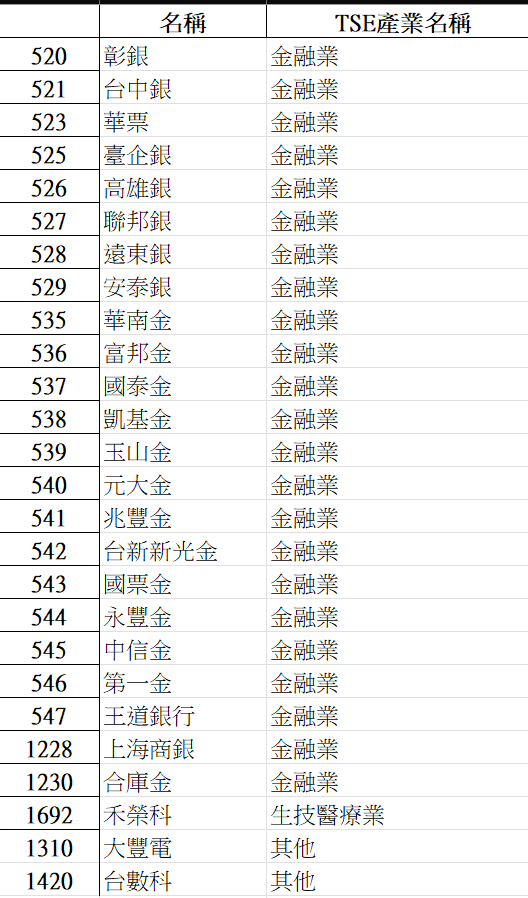

#### 結論 : 大部分汰除公司為金融業

In [26]:
from token import ENCODING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pearson_panelA = pd.read_csv("Pearson係數.csv",encoding="cp950")


In [29]:
# 2. 定義產出論文格式相關係數表的函數
from scipy.stats import pearsonr
def paper_format_corr(df):
    cols = df.columns
    # 建立一個空的 DataFrame 來存放格式化後的字串
    formatted_matrix = pd.DataFrame('', columns=cols, index=cols)
    
    for i in range(len(cols)):
        for j in range(len(cols)):
            col1 = cols[i]
            col2 = cols[j]
            
            # 對角線固定為 1.0000
            if i == j:
                formatted_matrix.iloc[i, j] = '1.0000'
                
            # 只處理下半三角
            elif i > j: 
                # 計算 pearson r 與 p-value
                r, p = pearsonr(df[col1], df[col2])
                
                # 判斷顯著性並給予對應字母 (可依你的論文標準調整)
                sig_mark = ''
                if p < 0.01:
                    sig_mark = '***'
                elif p < 0.05:
                    sig_mark = '**'
                elif p < 0.10:
                    sig_mark = '*'
                    
                # 組合係數(小數點後四位)與顯著性標記
                formatted_matrix.iloc[i, j] = f"{r:.4f}{sig_mark}"
                
            # 上半三角保持空字串
            else:
                formatted_matrix.iloc[i, j] = '' 
                
    return formatted_matrix

# 3. 執行函數並印出結果
result_table = paper_format_corr(pearson_panelA)

# 為了讓外觀更像你的圖，我們可以把 index 加上 (1), (2)... 的前綴
result_table.index = [f"({i+1}){col}" for i, col in enumerate(result_table.index)]
result_table.columns = [f"({i+1})" for i in range(len(result_table.columns))]

print(result_table)
# 4. 如果你想要把結果輸出成 CSV 或 Excel，可以使用以下程式碼：
result_table.to_excel("correlation_table_假設1.xlsx") 

                         (1)         (2)         (3)        (4)        (5)  \
(1)資產總額_自然變數          1.0000                                                 
(2)槓桿比             0.2567***      1.0000                                     
(3)現金比率           -0.2756***  -0.2041***      1.0000                         
(4)資產報酬率(2024全年)   0.2312***  -0.0663***   0.1135***     1.0000              
(5)OI                 0.0228      0.0220  -0.0874***  0.0804***     1.0000   
(6)董事會規模           0.3077***   0.0638***  -0.0993***  0.0871***     0.0001   
(7)董事會獨立性         -0.1410***     -0.0356   0.0800***     0.0065  -0.0486**   
(8)董事長兼任總經理       -0.0661***     -0.0232    0.0573**   0.0533**     0.0184   
(9)高階主管薪酬長期目標       0.0504**     -0.0077     -0.0275     0.0253     0.0038   
(10)AI變數              0.0298  -0.0825***   0.1313***     0.0213     0.0282   
(11)現金充裕度          0.2952***      0.0204      0.0126   0.0512**     0.0045   
(12)累計報酬率             0.0019    0.0476**     -0.0365    -0.0336 

In [25]:
print(pearson_panelA.isnull().sum())
print(pearson_panelA["現金充裕度"][pearson_panelA["現金充裕度"].isnull()])

資產總額_自然變數        0
槓桿比              0
現金比率             0
資產報酬率(2024全年)    0
OI               0
董事會規模            0
董事會獨立性           0
董事長兼任總經理         0
高階主管薪酬長期目標       0
AI變數             0
現金充裕度            1
累計報酬率            0
集團控制型態_量化        0
TESG分數           0
dtype: int64
1396   NaN
Name: 現金充裕度, dtype: float64


## Pearson 係數表 - 額外測試

In [ ]:
pearson_cat1 = pd.read_excel("pearson係數_進一步測試.xlsx", sheet_name='維度1')
print(pearson_cat1.isnull().sum())

代號                0
名稱                0
TSE產業名稱           0
資產總額_自然變數         0
槓桿比               0
現金比率             23
資產報酬率(2024全年)     0
OI               24
董事會規模             0
董事會獨立性            0
董事長兼任總經理          0
高階主管薪酬長期目標        0
現金充裕度             2
集團控制型態_量化         0
TESG分數            0
維度1_事件衝擊          0
累計報酬率             0
dtype: int64


#### 分別找出各欄有缺失值的公司


In [53]:
cash_ratio_null_company= pearson_cat1[["名稱","TSE產業名稱"]][pearson_cat1["現金比率"].isnull()]
print(cash_ratio_null_company)
cash_ratio_null_company.to_excel("現金比率缺值公司.xlsx")

         名稱 TSE產業名稱
520      彰銀     金融業
521     台中銀     金融業
523      華票     金融業
525     臺企銀     金融業
526     高雄銀     金融業
527     聯邦銀     金融業
528     遠東銀     金融業
529     安泰銀     金融業
535     華南金     金融業
536     富邦金     金融業
537     國泰金     金融業
538     凱基金     金融業
539     玉山金     金融業
540     元大金     金融業
541     兆豐金     金融業
542   台新新光金     金融業
543     國票金     金融業
544     永豐金     金融業
545     中信金     金融業
546     第一金     金融業
547    王道銀行     金融業
1228   上海商銀     金融業
1230    合庫金     金融業


In [54]:
oi_null_company= pearson_cat1[["名稱","TSE產業名稱"]][pearson_cat1["OI"].isnull()]
print(oi_null_company)

         名稱 TSE產業名稱
520      彰銀     金融業
521     台中銀     金融業
523      華票     金融業
525     臺企銀     金融業
526     高雄銀     金融業
527     聯邦銀     金融業
528     遠東銀     金融業
529     安泰銀     金融業
535     華南金     金融業
536     富邦金     金融業
537     國泰金     金融業
538     凱基金     金融業
539     玉山金     金融業
540     元大金     金融業
541     兆豐金     金融業
542   台新新光金     金融業
543     國票金     金融業
544     永豐金     金融業
545     中信金     金融業
546     第一金     金融業
547    王道銀行     金融業
1228   上海商銀     金融業
1230    合庫金     金融業
1692    禾榮科   生技醫療業


In [55]:
cash_adequacy_company= pearson_cat1[["名稱","TSE產業名稱"]][pearson_cat1["現金充裕度"].isnull()]
print(cash_adequacy_company)

       名稱 TSE產業名稱
1310  大豐電      其他
1420  台數科      其他


#### 分別編列維度 1 + 2 + 3 的Pearson係數表

In [59]:
pearson_cat1 = pd.read_excel("pearson係數_進一步測試.xlsx", sheet_name='維度1')
pearson_cat2=pd.read_excel("pearson係數_進一步測試.xlsx", sheet_name='維度2')
pearson_cat3=pd.read_excel("pearson係數_進一步測試.xlsx", sheet_name='維度3')
result_table_cat1 = paper_format_corr(pearson_cat1)
result_table_cat2 = paper_format_corr(pearson_cat2)
result_table_cat3 = paper_format_corr(pearson_cat3)
result_table_cat1.to_excel("correlation_table_假設1_維度1.xlsx") 
result_table_cat2.to_excel("correlation_table_假設1_維度2.xlsx") 
result_table_cat3.to_excel("correlation_table_假設1_維度3.xlsx") 